# BigMart Sales Prediction — EDA & Problem Framing

## Business Context
BigMart wants to predict sales for each product at each outlet and understand which product and outlet characteristics drive revenue.
The goal of this notebook is to:
- Understand the data structure
- Identify data quality issues
- Explore key patterns in sales
- Inform downstream feature engineering and modeling choices



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

%matplotlib inline



In [3]:
train_path = "/Users/lj/Desktop/bigmart-sales-prediction/bigmart-sales-prediction/data/raw/train.csv"
test_path = "/Users/lj/Desktop/bigmart-sales-prediction/bigmart-sales-prediction/data/raw/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (8523, 12)
Test shape: (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
train.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Train duplicates:", train.duplicated().sum())
print("Test duplicates:", test.duplicated().sum())



Train duplicates: 0
Test duplicates: 0


In [7]:
## Target variable distribution
target_col = "Item_Outlet_Sales"

train[target_col].describe()


count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

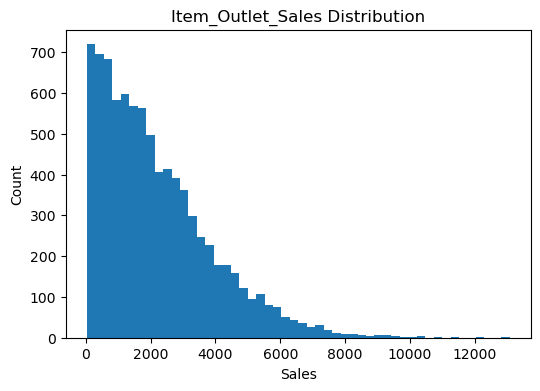

In [8]:
# Plotting the distribution of the target variable
plt.figure(figsize=(6,4))
plt.hist(train[target_col], bins=50)
plt.title("Item_Outlet_Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()


# Raw Item_Outlet_Sales distribution


## Most observations are small sales values (close to 0–2000)

A long tail extends to very large values (up to ~13,000)

This is a strong right-skewed distribution

Most product–outlet pairs sell a little, and a few sell a lot.

## This is extremely common in retail:

Bestseller items

High-traffic stores

Popular categories

## Key issue with this shape

The model will focus too much on large sales values

Errors on large numbers dominate the loss

Small and medium sales get “ignored”

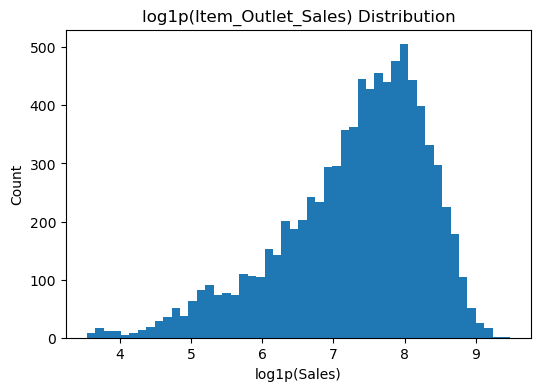

In [12]:
# Log-transformed Distribution
plt.figure(figsize=(6,4))
plt.hist(np.log1p(train[target_col]), bins=50)
plt.title("log1p(Item_Outlet_Sales) Distribution")
plt.xlabel("log1p(Sales)")
plt.ylabel("Count")
plt.show()


## Now look at (log1p(Item_Outlet_Sales)):

## Distribution is much more symmetric

Values are more evenly spread

Extreme outliers are compressed

The shape is closer to a bell curve

This is exactly what we want for most ML models.

## In retail, relative errors matter more than absolute errors.

Example:

Predict 100 → actual 200 → error = 100 (bad)

Predict 5,000 → actual 5,100 → error = 100 (not bad)

## But RMSE treats them the same.

Log transformation turns this into:

Predicting percentage differences, not raw units

So:

Log models care about proportional accuracy, not absolute scale.

What log transformation does mathematically

When you model:

y_log = log1p(y)




# “I want my model to minimize relative error, not absolute error.”

Also:

log(1 + y) avoids problems with zero sales

Large values are compressed

Variance becomes more stable (homoscedasticity)

### Target Distribution Observation

The raw `Item_Outlet_Sales` distribution is highly right-skewed, with a small number of product–outlet combinations accounting for very large sales volumes. This long-tailed behavior can cause models trained on raw sales to overemphasize high-volume observations and underperform on the majority of items.

After applying a `log1p` transformation, the target distribution becomes much more symmetric and evenly distributed. This transformation compresses extreme values, stabilizes variance, and allows the model to focus on proportional rather than absolute errors.

Based on these observations, subsequent models will be trained to predict `log1p(Item_Outlet_Sales)`, with predictions converted back to the original scale for evaluation and interpretation.


In [13]:
# Missing Values Analysis
def missing_report(df):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return (miss * 100).round(2)

print("Train missing %:")
display(missing_report(train))

print("Test missing %:")
display(missing_report(test))


Train missing %:


Outlet_Size    28.28
Item_Weight    17.17
dtype: float64

Test missing %:


Outlet_Size    28.27
Item_Weight    17.18
dtype: float64

**Observation**
- Some product and outlet attributes contain missing values.
- Missingness needs to be handled carefully to avoid bias and information leakage.


In [14]:
# Suspicious Zeros (Item_Visibility)
if "Item_Visibility" in train.columns:
    print("Train Item_Visibility == 0 (%):",
          round((train["Item_Visibility"] == 0).mean() * 100, 2))
    print("Test Item_Visibility == 0 (%):",
          round((test["Item_Visibility"] == 0).mean() * 100, 2))


Train Item_Visibility == 0 (%): 6.17
Test Item_Visibility == 0 (%): 6.21


In [15]:
# Data Types Analysis
categorical_cols = train.select_dtypes(include="object").columns.tolist()
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols, numeric_cols


(['Item_Identifier',
  'Item_Fat_Content',
  'Item_Type',
  'Outlet_Identifier',
  'Outlet_Size',
  'Outlet_Location_Type',
  'Outlet_Type'],
 ['Item_Weight',
  'Item_Visibility',
  'Item_MRP',
  'Outlet_Establishment_Year',
  'Item_Outlet_Sales'])

In [16]:
# Sales by Outlet_Size/ Attributes
group_col = "Outlet_Type"

if group_col in train.columns:
    outlet_summary = (
        train.groupby(group_col)[target_col]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )
    display(outlet_summary)


,count,mean,median
Outlet_Type,,,
Supermarket Type3,935,3694.038558,3364.9532
Supermarket Type1,5577,2316.181148,1990.7420
Supermarket Type2,928,1995.498739,1655.1788
Grocery Store,1083,339.828500,256.9988


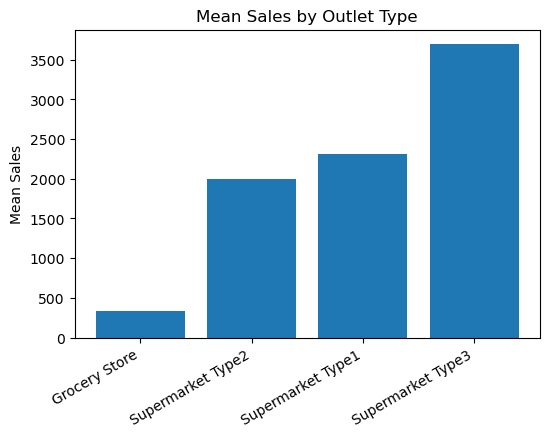

In [17]:
if group_col in train.columns:
    tmp = train.groupby(group_col)[target_col].mean().sort_values()
    plt.figure(figsize=(6,4))
    plt.bar(tmp.index.astype(str), tmp.values)
    plt.title("Mean Sales by Outlet Type")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Mean Sales")
    plt.show()


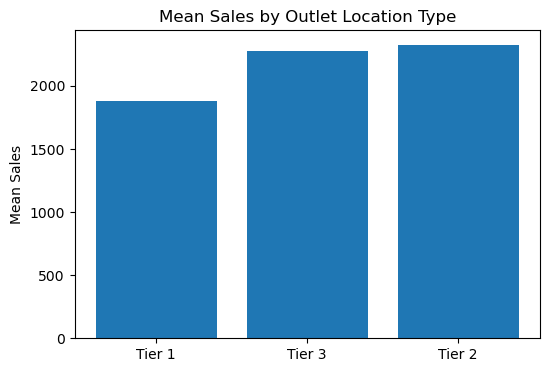

In [18]:
# sales by Outlet_Location_Type
group_col = "Outlet_Location_Type"

if group_col in train.columns:
    tmp = train.groupby(group_col)[target_col].mean().sort_values()
    plt.figure(figsize=(6,4))
    plt.bar(tmp.index.astype(str), tmp.values)
    plt.title("Mean Sales by Outlet Location Type")
    plt.ylabel("Mean Sales")
    plt.show()


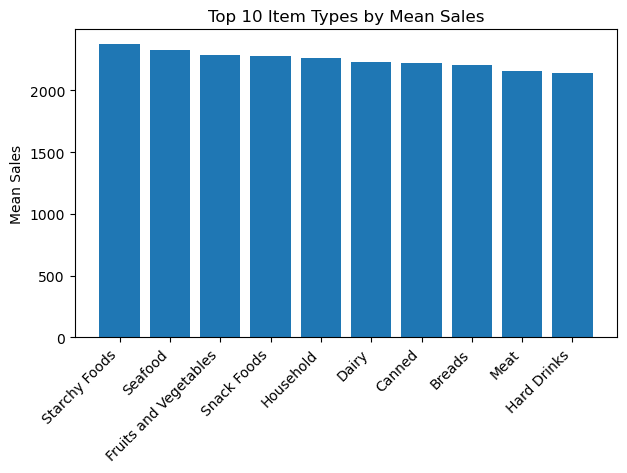

In [19]:
# Top 10 Item Types by Mean Sales
group_col = "Item_Type"

if group_col in train.columns:
    top_items = (
        train.groupby(group_col)[target_col]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(7,4))
    plt.bar(top_items.index.astype(str), top_items.values)
    plt.title("Top 10 Item Types by Mean Sales")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean Sales")
    plt.show()


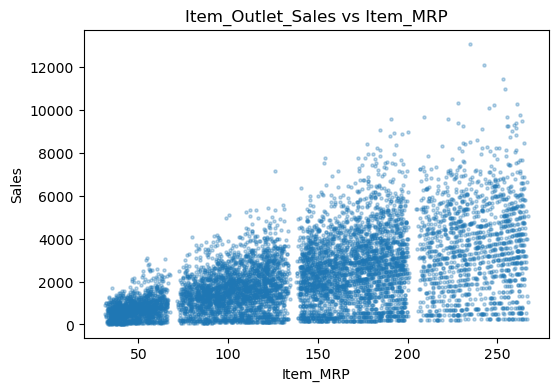

In [21]:
# Numeric feature analysis - Item MRP vs Sales
if "Item_MRP" in train.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(train["Item_MRP"], train[target_col], s=5, alpha=0.3)
    plt.title("Item_Outlet_Sales vs Item_MRP")
    plt.xlabel("Item_MRP")
    plt.ylabel("Sales")
    plt.show()
